c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



🔹 Random Forest for UTS
✅ R²: 0.9431
✅ RMSE: 0.1108
✅ MAE: 0.0672
✅ MAPE: 0.70%


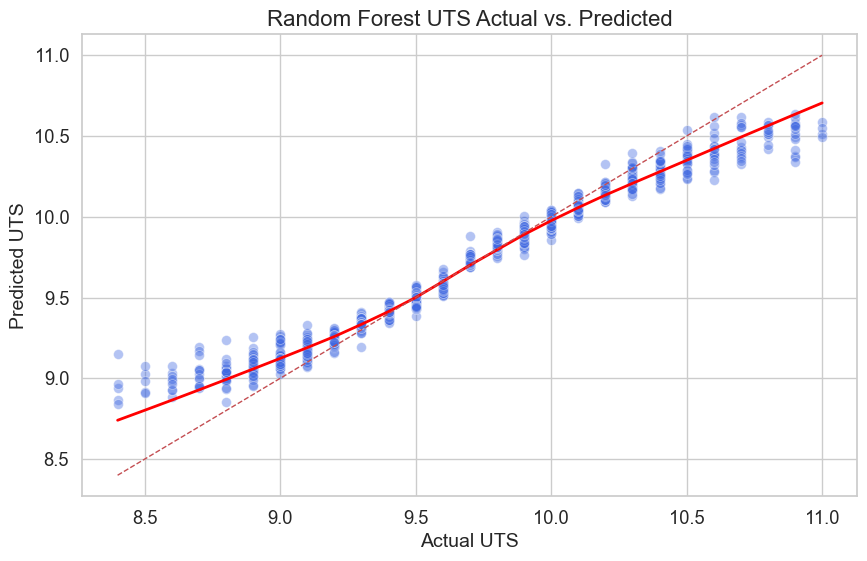

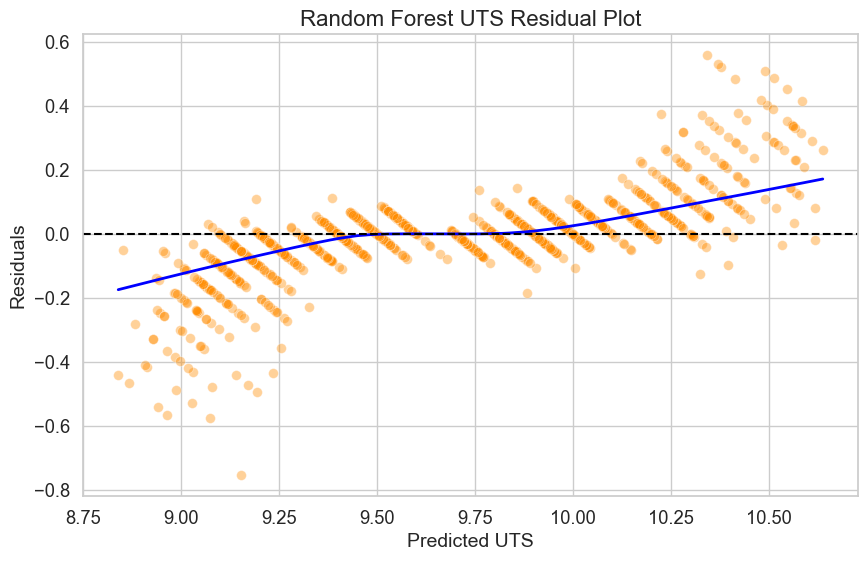

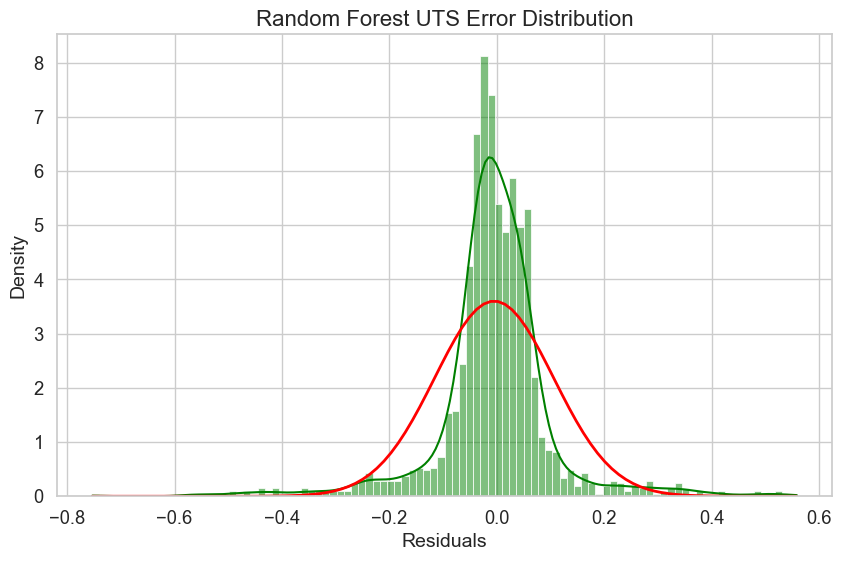

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: '

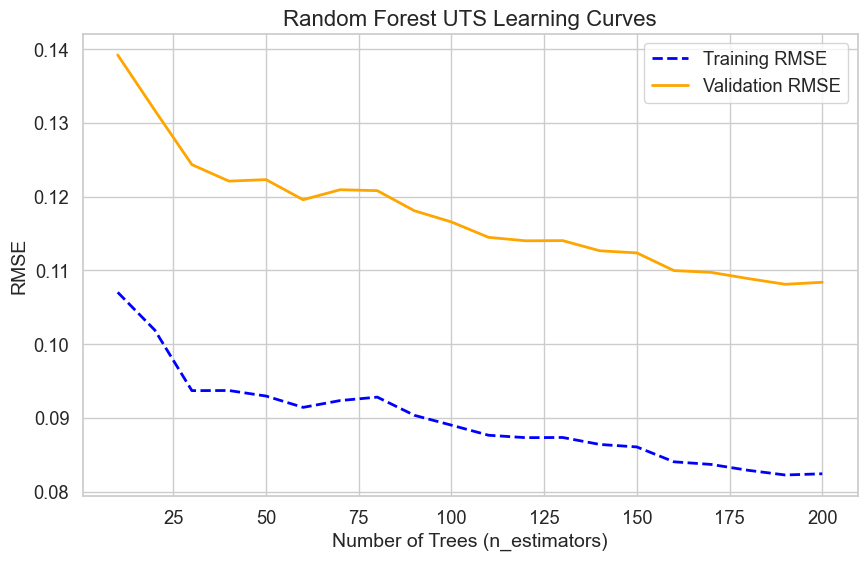

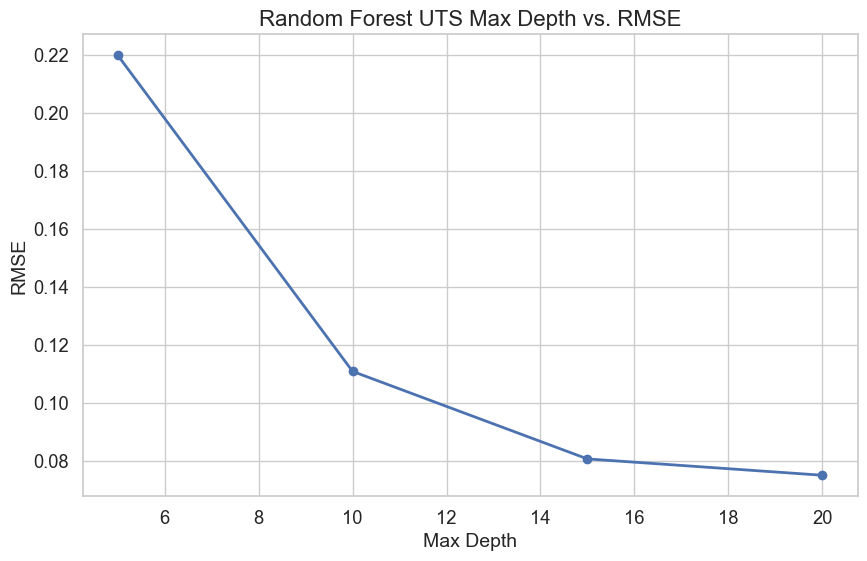

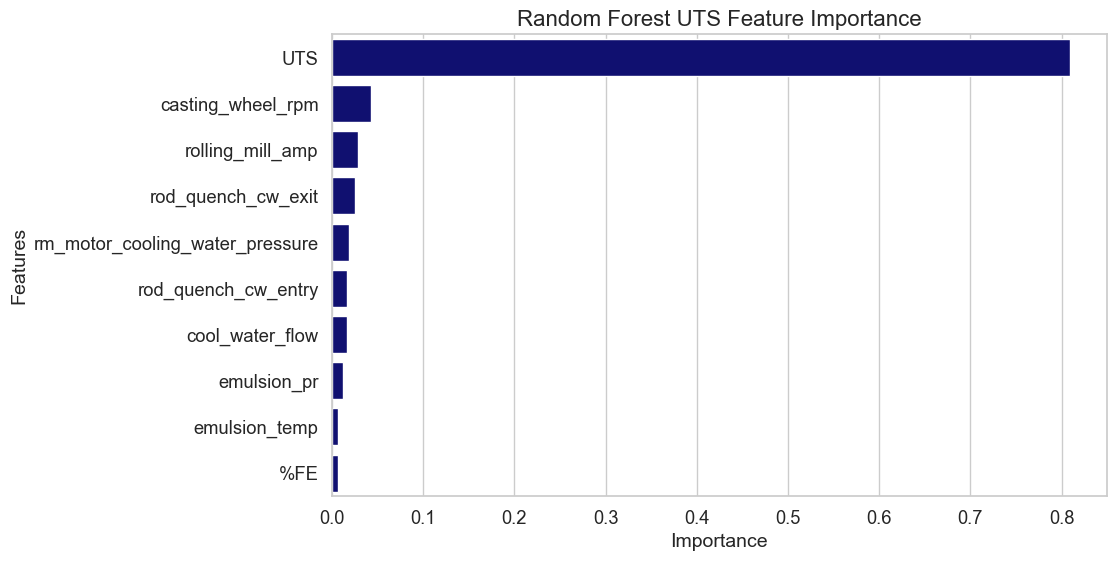

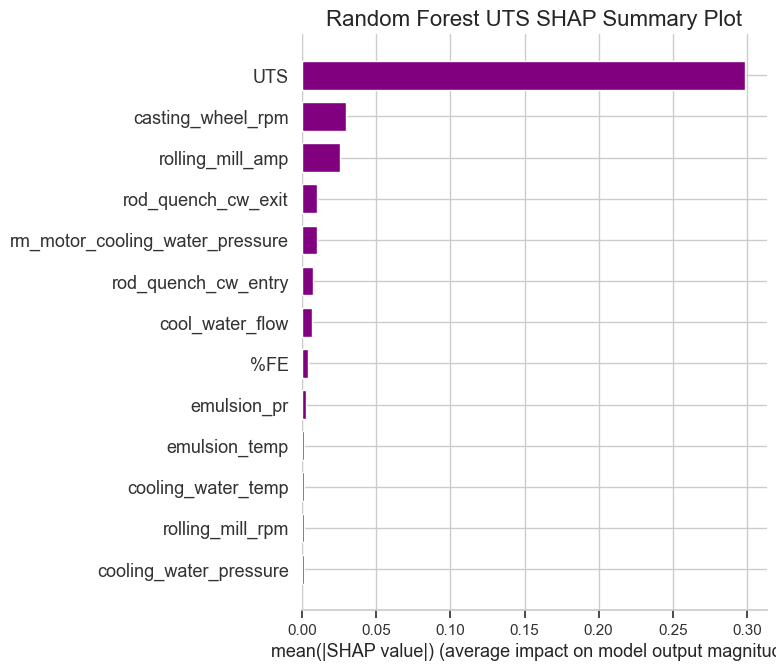

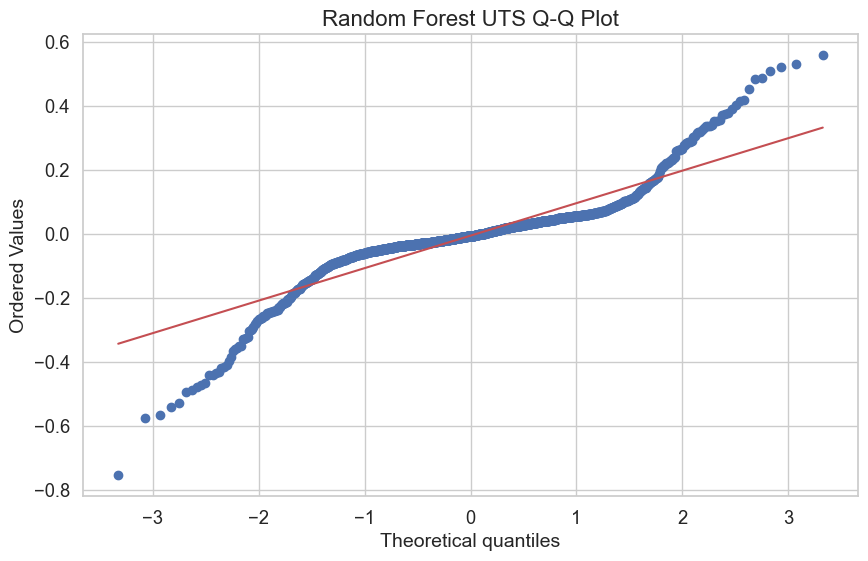

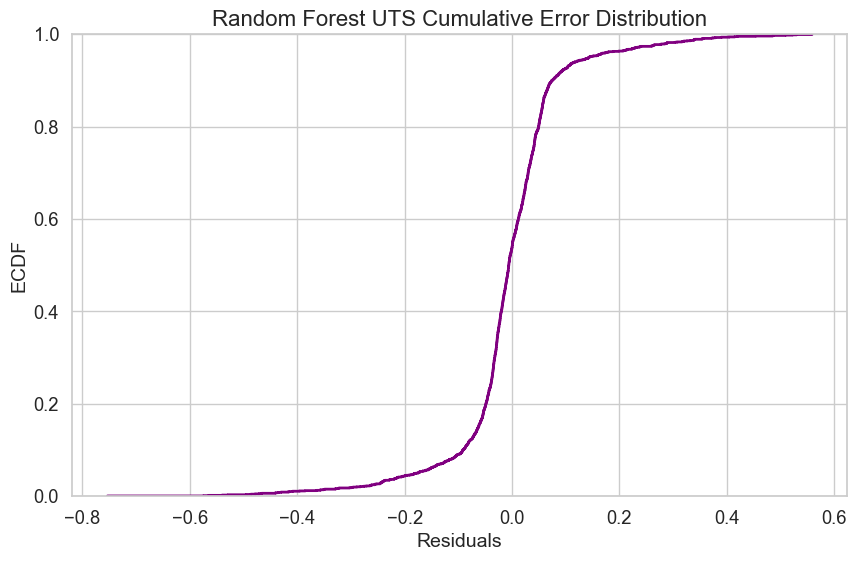

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df.drop_duplicates(inplace=True)

# ✅ Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# ✅ Define columns to exclude (but keep "UTS" as target)
columns_to_exclude = ["Conductivity", "elongation", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define Random Forest hyperparameters
params_uts = {
    "n_estimators": 200,  # ✅ More trees for stability
    "max_depth": 10,  # ✅ Limiting depth to reduce overfitting
    "min_samples_split": 5,  # ✅ Minimum samples to split an internal node
    "min_samples_leaf": 2,  # ✅ Minimum samples at a leaf node
    "max_features": "sqrt",  # ✅ Selecting features wisely
    "bootstrap": True,  # ✅ Bootstrapping for variance reduction
    "random_state": 42,
    "n_jobs": -1  # ✅ Use all available CPU cores
}

# ✅ Train Random Forest model for UTS
rf_model_uts = RandomForestRegressor(**params_uts)
rf_model_uts.fit(X_train, y_train)

# ✅ Predict on Train & Test
y_train_pred = rf_model_uts.predict(X_train)
y_test_pred = rf_model_uts.predict(X_test)

# ✅ Clip predictions to real data range
y_train_pred = np.clip(y_train_pred, y_train.min(), y_train.max())
y_test_pred = np.clip(y_test_pred, y_train.min(), y_train.max())

# ✅ Compute Metrics
r2 = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 Random Forest for UTS")
print(f"✅ R²: {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

# ✅ Residuals
residuals_uts = y_test - y_test_pred

# ✅ Visualizations
output_dir_uts = "randomforest_uts_plots"
os.makedirs(output_dir_uts, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("Random Forest UTS Actual vs. Predicted")
plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.savefig(f"{output_dir_uts}/RF_UTS_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals_uts, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals_uts, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("Random Forest UTS Residual Plot")
plt.xlabel("Predicted UTS")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir_uts}/RF_UTS_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals_uts, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals_uts.min(), residuals_uts.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals_uts.mean(), residuals_uts.std()), color="red", linewidth=2)
plt.title("Random Forest UTS Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir_uts}/RF_UTS_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Learning Curves (Track Train & Validation RMSE)
train_rmse = [mean_squared_error(y_train, rf_model_uts.predict(X_train), squared=False)]
validation_rmse = [mean_squared_error(y_val, rf_model_uts.predict(X_val), squared=False)]

for n_estimators in range(10, 201, 10):  # Train with increasing number of trees
    rf_model_uts.set_params(n_estimators=n_estimators)
    rf_model_uts.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, rf_model_uts.predict(X_train), squared=False))
    validation_rmse.append(mean_squared_error(y_val, rf_model_uts.predict(X_val), squared=False))

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(range(10, 201, 10), train_rmse[1:], '--', label='Training RMSE', color='blue', linewidth=2)
plt.plot(range(10, 201, 10), validation_rmse[1:], '-', label='Validation RMSE', color='orange', linewidth=2)
plt.title("Random Forest UTS Learning Curves")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("RMSE")
plt.legend()
plt.savefig(f"{output_dir_uts}/RF_UTS_Learning_Curves.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 5. Hyperparameter vs. Error Plot (Learning Rate Experiment)
# Removed "learning_rate" as it is not applicable for RandomForest
# Example of other hyperparameters tuning, like "max_depth" or "min_samples_split"

max_depths = [5, 10, 15, 20]
errors_uts = []
for max_depth in max_depths:
    temp_params = params_uts.copy()
    temp_params["max_depth"] = max_depth
    model = RandomForestRegressor(**temp_params)
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    rmse_uts = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors_uts.append(rmse_uts)

plt.figure(figsize=(10, 6))
plt.plot(max_depths, errors_uts, marker='o', linewidth=2)
plt.title("Random Forest UTS Max Depth vs. RMSE")
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir_uts}/RF_UTS_MaxDepth_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Feature Importance
# ✅ Feature Importance using RandomForest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model_uts.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, color="navy")
plt.title("Random Forest UTS Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir_uts}/RF_UTS_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. SHAP Summary Plot
explainer_uts = shap.TreeExplainer(rf_model_uts)
shap_values_uts = explainer_uts.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_uts, X_test, plot_type="bar", show=False, color='purple')
plt.title("Random Forest UTS SHAP Summary Plot")
plt.savefig(f"{output_dir_uts}/RF_UTS_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals_uts, dist="norm", plot=plt)
plt.title("Random Forest UTS Q-Q Plot")
plt.savefig(f"{output_dir_uts}/RF_UTS_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals_uts, color="purple", linewidth=2)
plt.title("Random Forest UTS Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir_uts}/RF_UTS_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()